In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Gaffar\OneDrive\Desktop\FMCG_Sales_Data.csv\FMCG_2022_2024.csv')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df.head()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold,year,month
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9,2022,1
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0,2022,1
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8,2022,1
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7,2022,1
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12,2022,1


In [3]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.describe()

Shape: (190757, 16)

Missing Values:
 date               0
sku                0
brand              0
segment            0
category           0
channel            0
region             0
pack_type          0
price_unit         0
promotion_flag     0
delivery_days      0
stock_available    0
delivered_qty      0
units_sold         0
year               0
month              0
dtype: int64


,date,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold,year,month
count,190757,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000
mean,2023-10-28 04:11:33.514785536,5.251979,0.149200,3.004860,157.697652,179.333655,19.919709,2023.286815,6.953223
min,2022-01-21 00:00:00,1.500000,0.000000,1.000000,-12.000000,-11.000000,-25.000000,2022.000000,1.000000
25%,2023-04-16 00:00:00,3.380000,0.000000,2.000000,124.000000,152.000000,12.000000,2023.000000,4.000000
50%,2023-11-12 00:00:00,5.250000,0.000000,3.000000,155.000000,179.000000,18.000000,2023.000000,7.000000
75%,2024-06-07 00:00:00,7.130000,0.000000,4.000000,192.000000,206.000000,25.000000,2024.000000,10.000000
max,2024-12-31 00:00:00,9.000000,1.000000,5.000000,405.000000,366.000000,139.000000,2024.000000,12.000000
std,NaN,2.166705,0.356287,1.414626,52.736104,40.037475,11.770077,0.714987,3.374958


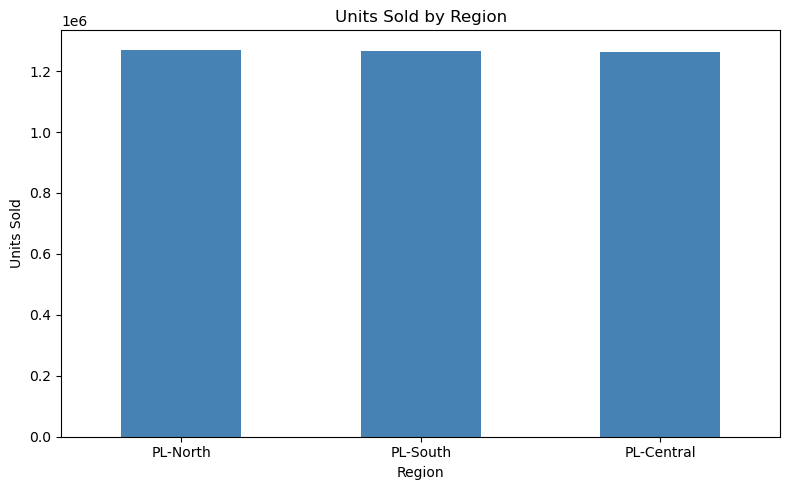

In [4]:
region_sales = df.groupby('region')['units_sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Units Sold by Region')
plt.xlabel('Region')
plt.ylabel('Units Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

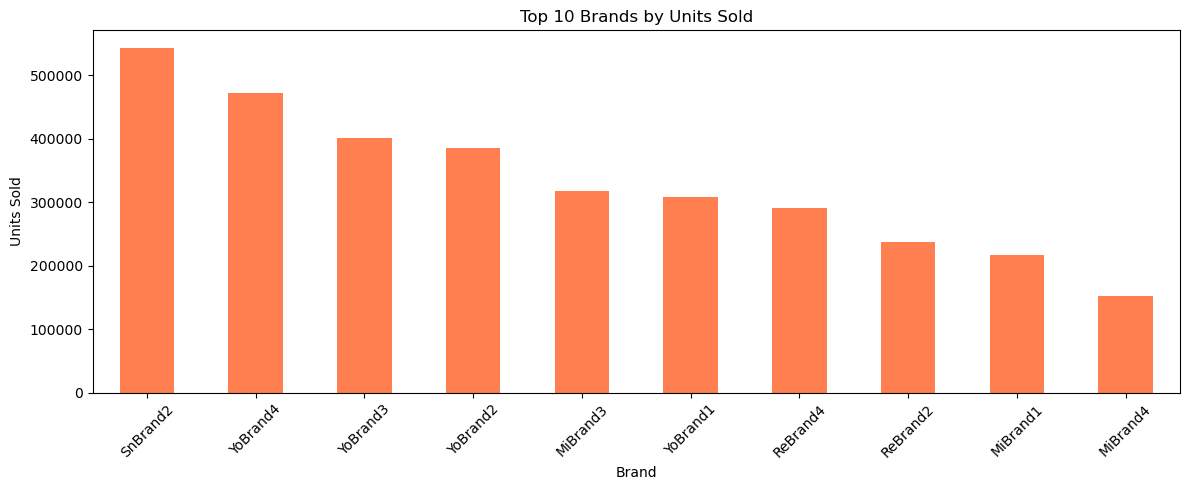

In [5]:
brand_sales = df.groupby('brand')['units_sold'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
brand_sales.plot(kind='bar', color='coral')
plt.title('Top 10 Brands by Units Sold')
plt.xlabel('Brand')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

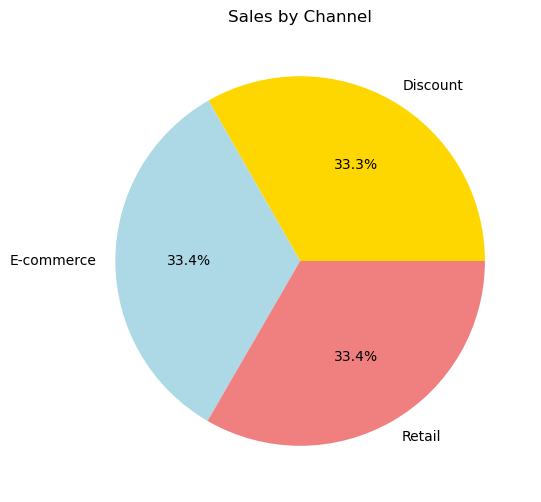

In [6]:
channel_sales = df.groupby('channel')['units_sold'].sum()

plt.figure(figsize=(6,6))
plt.pie(channel_sales, labels=channel_sales.index, autopct='%1.1f%%', colors=['gold','lightblue','lightcoral'])
plt.title('Sales by Channel')
plt.show()

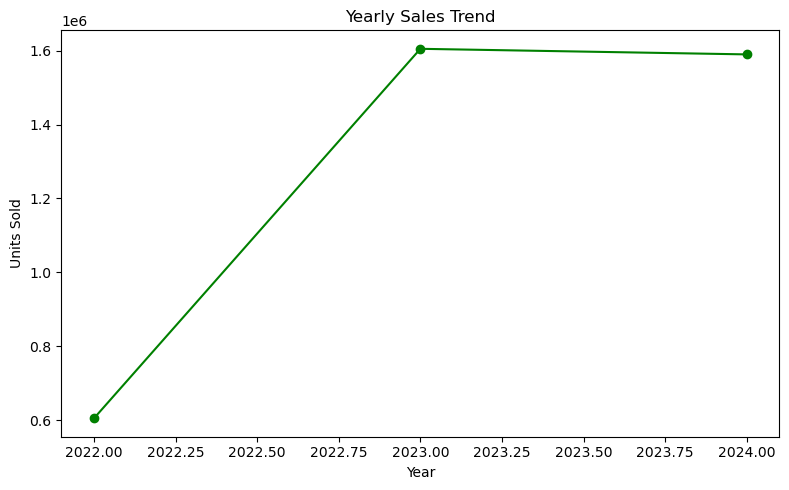

In [7]:
yearly_sales = df.groupby('year')['units_sold'].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='line', marker='o', color='green')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

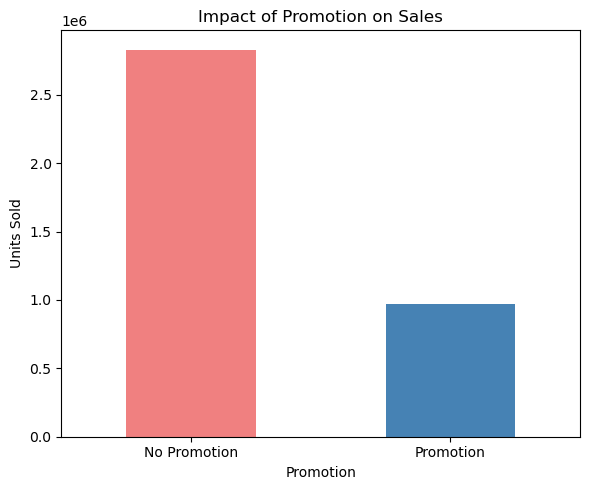

In [8]:
promo_sales = df.groupby('promotion_flag')['units_sold'].sum()
promo_sales.index = ['No Promotion', 'Promotion']

plt.figure(figsize=(6,5))
promo_sales.plot(kind='bar', color=['lightcoral','steelblue'])
plt.title('Impact of Promotion on Sales')
plt.xlabel('Promotion')
plt.ylabel('Units Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

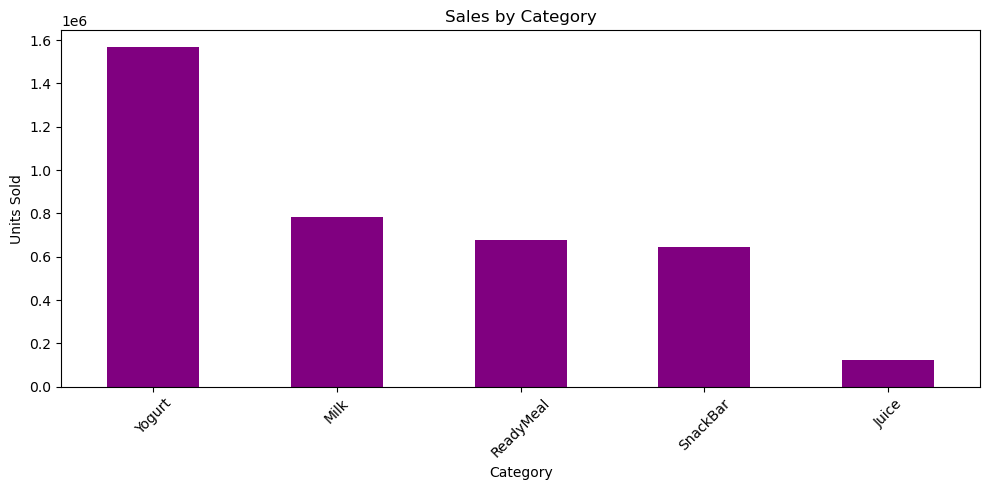

In [9]:
category_sales = df.groupby('category')['units_sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_sales.plot(kind='bar', color='purple')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()